### Contextualização

#### Introdução

Este desafio utiliza o dataset [Chest X-Ray Images (Pneumonia) - Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) para estudar um problema de **classificação supervisionada de imagens médicas**. O objetivo é classificar radiografias de tórax em duas classes: **NORMAL**, quando não há sinais de pneumonia, e **PNEUMONIA**, quando a imagem apresenta indícios da doença.

O problema é relevante para a área de Reconhecimento de Padrões porque envolve a identificação de características visuais em imagens, como textura, contraste e regiões de opacidade pulmonar. Como os dados são imagens médicas, o processo exige etapas de pré-processamento, análise exploratória e avaliação do desempenho dos modelos.

O dataset é composto por radiografias torácicas pediátricas em formato JPEG, organizadas nos subconjuntos **train**, **val** e **test**, cada um contendo as classes **NORMAL** e **PNEUMONIA**. As imagens são provenientes de pacientes entre 1 e 5 anos de idade atendidos no Guangzhou Women and Children’s Medical Center, na China. Antes da disponibilização, as imagens passaram por um processo de controle de qualidade, com remoção de exames de baixa qualidade ou ilegíveis.

#### Exploração Inicial

A análise inicial dos dados mostra que o conjunto está dividido em três partes: treinamento, validação e teste. A distribuição das imagens por classe está da seguinte forma:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treino      |  1.342 |     3.876 | 5.218 |
| Validação   |      9 |         9 |    18 |
| Teste       |    235 |       391 |   626 |

Observa-se que o conjunto de treinamento é desbalanceado, com uma quantidade maior de imagens da classe **PNEUMONIA**. Esse desbalanceamento pode influenciar o treinamento dos modelos, tornando necessário o uso de métricas além da acurácia, como precisão, recall e F1-score.


In [41]:
# imports

import os
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.models import MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU: NVIDIA GeForce 940MX


In [42]:
# settings

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
SPLIT_NAMES = ["train", "val", "test"]

MAX_EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 0.001
BATCH_SIZE = 32
NUM_WORKERS = 2
FINAL_THRESHOLD = 0.5

IMG_EXTENSIONS = ".jpeg"

UNBALANCED_BEST_MODEL_PATH = "trained-models/exp4/best_mobilenetv2_unbalanced.pth"
UNDERSAMPLED_BEST_MODEL_PATH = "trained-models/exp4/best_mobilenetv2_undersampled.pth"
OVERSAMPLED_BEST_MODEL_PATH = "trained-models/exp4/best_mobilenetv2_oversampled.pth"

ORIGINAL_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/chest_xray")
UNBALANCED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento4/unbalanced_chest_xray")
UNDERSAMPLED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento4/undersampled_chest_xray")
OVERSAMPLED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/experimento4/oversampled_chest_xray")

### Preparação

Na etapa de preparação dos dados, serão realizados dois experimentos com o objetivo de comparar o desempenho da rede neural em cenários com diferentes distribuições entre as classes **NORMAL** e **PNEUMONIA**.

O **dataset original** será utilizado apenas como fonte inicial das imagens, não sendo treinado diretamente na divisão original disponibilizada pelo Kaggle. A divisão original possui um conjunto de validação muito pequeno, com apenas 16 imagens. Por esse motivo, as imagens dos conjuntos originais de **treinamento** e **validação** serão agrupadas para formar uma nova base de treino e validação. O conjunto de **teste** original será mantido separado e será utilizado igualmente nos dois experimentos, permitindo uma comparação justa entre os modelos.

A distribuição inicial do dataset original é apresentada a seguir:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.341 |     3.875 | 5.216 |
| Validação   |      8 |         8 |    16 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     4.273 | 5.856 |

No **primeiro experimento**, será criado um dataset **desbalanceado** a partir da junção dos conjuntos originais de treinamento e validação. Após essa junção, 20% das imagens serão separadas para validação e os 90% restantes serão utilizados para treinamento. Essa divisão mantém o desbalanceamento natural entre as classes, com maior quantidade de imagens da classe **PNEUMONIA**.

A divisão utilizada no primeiro experimento será:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.079 |     3.106 | 4.185 |
| Validação   |    270 |       777 | 1.047 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     4.273 | 5.856 |

No **segundo experimento**, será criado um dataset **balanceado** utilizando a técnica de **undersampling** apenas no conjunto de treinamento. Essa técnica consiste em reduzir a quantidade de amostras da classe majoritária até que ela tenha o mesmo número de imagens da classe minoritária. Assim, serão mantidas todas as imagens da classe **NORMAL** no treinamento e será selecionada aleatoriamente a mesma quantidade de imagens da classe **PNEUMONIA**.

As imagens de **validação** e **teste** serão as mesmas utilizadas no primeiro experimento. Dessa forma, a única diferença entre os dois experimentos estará no conjunto de treinamento, permitindo avaliar diretamente o impacto do balanceamento sobre o aprendizado do modelo.

A divisão utilizada no segundo experimento será:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treinamento |  1.079 |     1.079 | 2.158 |
| Validação   |    270 |       777 | 1.047 |
| Teste       |    234 |       390 |   624 |
| **Total**   |  1.583 |     1.992 | 3.575 |

Com essa organização, o primeiro experimento avalia o desempenho da rede neural em um cenário desbalanceado, enquanto o segundo avalia o efeito do balanceamento por undersampling no conjunto de treinamento. Como os conjuntos de validação e teste são mantidos iguais nos dois experimentos, a comparação entre os resultados torna-se mais consistente.


In [43]:
# Criação dos datasets dos 3 experimentos a partir do dataset original.
#
# Estratégia geral:
# - todas as imagens originais de train, val e test são agrupadas por classe;
# - para cada classe, são reservadas exatamente 250 imagens para validação;
# - para cada classe, são reservadas exatamente 250 imagens para teste;
# - o restante vai para treino.
#
# Importante:
# - os conjuntos de validação e teste são definidos uma única vez;
# - os 3 experimentos usam exatamente as mesmas imagens em val e test;
# - o balanceamento é aplicado somente no treino.

import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img


VAL_IMAGES_PER_CLASS = 250
TEST_IMAGES_PER_CLASS = 250
IMAGE_SIZE = (224, 224)


def list_image_paths_by_label(data_root, split_names=("train", "val", "test")):
    """Agrupa todas as imagens por classe, evitando duplicatas."""
    paths_by_label = {class_name: [] for class_name in CLASS_NAMES}
    seen_paths = set()

    for split_name in split_names:
        split_dir = Path(data_root) / split_name

        for class_name in CLASS_NAMES:
            class_dir = split_dir / class_name

            if not class_dir.exists():
                continue

            for image_path in class_dir.rglob("*"):
                if image_path.is_file() and image_path.suffix.lower() == IMG_EXTENSIONS:
                    resolved = image_path.resolve()

                    if resolved not in seen_paths:
                        paths_by_label[class_name].append(image_path)
                        seen_paths.add(resolved)

    return paths_by_label


def reset_dataset_dir(data_root):
    """Remove e recria a estrutura train/val/test por classe."""
    data_root = Path(data_root)

    if data_root.exists():
        shutil.rmtree(data_root)

    for split_name in SPLIT_NAMES:
        for class_name in CLASS_NAMES:
            (data_root / split_name / class_name).mkdir(parents=True, exist_ok=True)


def copy_pairs_to_dataset(split_pairs, output_root, image_size=IMAGE_SIZE):
    """Copia as imagens para o dataset de destino, redimensionando para o tamanho definido."""
    output_root = Path(output_root)

    for split_name, pairs in split_pairs.items():
        for i, (image_path, class_name) in enumerate(pairs):
            dst_name = f"{class_name}_{split_name}_{i:05d}_{Path(image_path).name}"
            dst_path = output_root / split_name / class_name / dst_name

            image = Image.open(image_path).convert("RGB")
            image = image.resize(image_size)
            image.save(dst_path)


def save_augmented_image(image_path, dst_path, datagen, image_size=IMAGE_SIZE, seed=None):
    """
    Gera uma nova imagem aumentada a partir de uma imagem original.

    Transformações usadas:
    - flip horizontal;
    - rotação pequena;
    - pequenos deslocamentos;
    - pequeno zoom.

    Não são usados:
    - flip vertical;
    - shear;
    - alterações fortes de brilho/cor.
    """
    image = Image.open(image_path).convert("RGB")
    image = image.resize(image_size)

    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    iterator = datagen.flow(
        image_array,
        batch_size=1,
        shuffle=False,
        seed=seed
    )

    augmented_array = next(iterator)[0]
    augmented_image = array_to_img(augmented_array)
    augmented_image.save(dst_path)


def print_dataset_counts(data_root):
    """Imprime a quantidade de imagens por split e por classe."""
    data_root = Path(data_root)

    for split_name in SPLIT_NAMES:
        print("|", split_name.upper())

        total = 0

        for class_name in CLASS_NAMES:
            class_dir = data_root / split_name / class_name
            count = len([
                p for p in class_dir.rglob("*")
                if p.is_file() and p.suffix.lower() == IMG_EXTENSIONS
            ])

            total += count
            print("|--", class_name, ":", count)

        print("Total", split_name, ":", total)


def print_split_counts_from_pairs(split_pairs, title):
    """Imprime a distribuição antes da cópia física dos arquivos."""
    print("\n" + title)

    for split_name in SPLIT_NAMES:
        counter = Counter(class_name for _, class_name in split_pairs[split_name])
        total = sum(counter.values())

        print("|", split_name.upper())
        for class_name in CLASS_NAMES:
            print("|--", class_name, ":", counter[class_name])

        print("Total", split_name, ":", total)


def create_base_split_from_original(original_root=ORIGINAL_DATA_ROOT):
    """
    Cria uma divisão base única.

    Essa divisão será usada pelos 3 experimentos para garantir que:
    - validação tenha exatamente as mesmas imagens;
    - teste tenha exatamente as mesmas imagens;
    - apenas o treino mude entre os experimentos.
    """
    paths_by_label = list_image_paths_by_label(
        data_root=original_root,
        split_names=("train", "val", "test")
    )

    rng = random.Random(SEED)

    split_pairs = {
        "train": [],
        "val": [],
        "test": []
    }

    for class_name in CLASS_NAMES:
        class_paths = sorted(paths_by_label[class_name])
        rng.shuffle(class_paths)

        required_images = VAL_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS

        if len(class_paths) < required_images:
            raise ValueError(
                f"A classe {class_name} possui apenas {len(class_paths)} imagens, "
                f"mas são necessárias pelo menos {required_images} imagens "
                f"para reservar {VAL_IMAGES_PER_CLASS} para validação e "
                f"{TEST_IMAGES_PER_CLASS} para teste."
            )

        val_paths = class_paths[:VAL_IMAGES_PER_CLASS]
        test_paths = class_paths[
            VAL_IMAGES_PER_CLASS:
            VAL_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS
        ]
        train_paths = class_paths[
            VAL_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS:
        ]

        split_pairs["train"].extend((path, class_name) for path in train_paths)
        split_pairs["val"].extend((path, class_name) for path in val_paths)
        split_pairs["test"].extend((path, class_name) for path in test_paths)

    return split_pairs


def create_unbalanced_dataset(base_split_pairs, output_root=UNBALANCED_DATA_ROOT):
    """
    Experimento 1:
    - treino desbalanceado;
    - validação igual para todos os experimentos;
    - teste igual para todos os experimentos.
    """
    unbalanced_split_pairs = {
        "train": list(base_split_pairs["train"]),
        "val": list(base_split_pairs["val"]),
        "test": list(base_split_pairs["test"])
    }

    reset_dataset_dir(output_root)
    copy_pairs_to_dataset(unbalanced_split_pairs, output_root)

    print("\nDataset desbalanceado criado em:", output_root)
    print_dataset_counts(output_root)

    return unbalanced_split_pairs


def create_undersampled_dataset(base_split_pairs, output_root=UNDERSAMPLED_DATA_ROOT):
    """
    Experimento 2:
    - undersampling apenas no treino;
    - reduz a classe majoritária até igualar a classe minoritária;
    - validação e teste permanecem exatamente iguais aos do experimento 1.
    """
    train_paths_by_label = {class_name: [] for class_name in CLASS_NAMES}

    for image_path, class_name in base_split_pairs["train"]:
        train_paths_by_label[class_name].append(image_path)

    min_train_count = min(
        len(paths)
        for paths in train_paths_by_label.values()
    )

    rng = random.Random(SEED)

    undersampled_train_pairs = []

    for class_name in CLASS_NAMES:
        selected_paths = rng.sample(
            train_paths_by_label[class_name],
            min_train_count
        )

        undersampled_train_pairs.extend(
            (path, class_name)
            for path in selected_paths
        )

    undersampled_split_pairs = {
        "train": undersampled_train_pairs,
        "val": list(base_split_pairs["val"]),
        "test": list(base_split_pairs["test"])
    }

    reset_dataset_dir(output_root)
    copy_pairs_to_dataset(undersampled_split_pairs, output_root)

    print("\nDataset com undersampling criado em:", output_root)
    print_dataset_counts(output_root)

    return undersampled_split_pairs


def create_oversampled_dataset(base_split_pairs, output_root=OVERSAMPLED_DATA_ROOT):
    """
    Experimento 3:
    - oversampling apenas da classe NORMAL no treino;
    - mantém todas as imagens originais do treino;
    - gera imagens aumentadas da classe NORMAL até igualar PNEUMONIA;
    - validação e teste permanecem exatamente iguais aos do experimento 1.
    """
    train_paths_by_label = {class_name: [] for class_name in CLASS_NAMES}

    for image_path, class_name in base_split_pairs["train"]:
        train_paths_by_label[class_name].append(image_path)

    normal_train_paths = train_paths_by_label["NORMAL"]
    pneumonia_train_paths = train_paths_by_label["PNEUMONIA"]

    normal_count = len(normal_train_paths)
    pneumonia_count = len(pneumonia_train_paths)

    if normal_count >= pneumonia_count:
        raise ValueError(
            "A classe NORMAL já possui quantidade igual ou maior que PNEUMONIA no treino. "
            "Oversampling da classe NORMAL não é necessário."
        )

    images_to_generate = pneumonia_count - normal_count

    normal_datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=False,
        shear_range=0.0,
        brightness_range=None,
        fill_mode="nearest"
    )

    oversampled_split_pairs = {
        "train": list(base_split_pairs["train"]),
        "val": list(base_split_pairs["val"]),
        "test": list(base_split_pairs["test"])
    }

    reset_dataset_dir(output_root)

    copy_pairs_to_dataset(oversampled_split_pairs, output_root)

    rng = random.Random(SEED)

    for i in range(images_to_generate):
        source_path = rng.choice(normal_train_paths)

        dst_name = f"NORMAL_train_aug_{i:05d}_{Path(source_path).stem}.jpeg"
        dst_path = Path(output_root) / "train" / "NORMAL" / dst_name

        save_augmented_image(
            image_path=source_path,
            dst_path=dst_path,
            datagen=normal_datagen,
            image_size=IMAGE_SIZE,
            seed=SEED + i
        )

    print("\nDataset com oversampling criado em:", output_root)
    print("Imagens NORMAL geradas por oversampling:", images_to_generate)
    print_dataset_counts(output_root)

    return oversampled_split_pairs


# Execução da criação dos datasets.
# Descomente quando quiser recriar os datasets.

# base_split_pairs = create_base_split_from_original()

# print_split_counts_from_pairs(
#     base_split_pairs,
#     "Distribuição base antes dos balanceamentos"
# )

# unbalanced_split_pairs = create_unbalanced_dataset(base_split_pairs)
# undersampled_split_pairs = create_undersampled_dataset(base_split_pairs)
# oversampled_split_pairs = create_oversampled_dataset(base_split_pairs)

In [44]:
# Classe que representa o dataset

class ChestXRayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    
# funcoes para montar os datasets de treino, validação e teste
def read_samples_by_folder(data_root, split_name):
    split_dir = Path(data_root) / split_name

    samples = []
    seen_paths = set()

    for label in CLASS_NAMES:
        class_dir = split_dir / label

        for image_path in class_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                resolved = image_path.resolve()
                
                if resolved not in seen_paths:
                    samples.append((str(image_path), CLASS_NAMES.index(label)))
                    seen_paths.add(resolved)
                    
    samples = sorted(samples, key=lambda x: x[0])
    return samples

def print_class_counts(name, samples):
    counts = Counter(label for _, label in samples)

    print(f"{name} images:", len(samples))
    print(f"|--NORMAL:", counts.get(0, 0))
    print(f"|--PNEUMONIA:", counts.get(1, 0))

In [45]:
unbalanced_train_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "train")
unbalanced_val_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "val")
unbalanced_test_samples = read_samples_by_folder(UNBALANCED_DATA_ROOT, "test")

print_class_counts("Train", unbalanced_train_samples)
print_class_counts("Validation", unbalanced_val_samples)
print_class_counts("Test", unbalanced_test_samples)

total_images = len(unbalanced_train_samples) + len(unbalanced_val_samples) + len(unbalanced_test_samples)
print("Total images used:", total_images)

Train images: 4856
|--NORMAL: 1083
|--PNEUMONIA: 3773
Validation images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Test images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Total images used: 5856


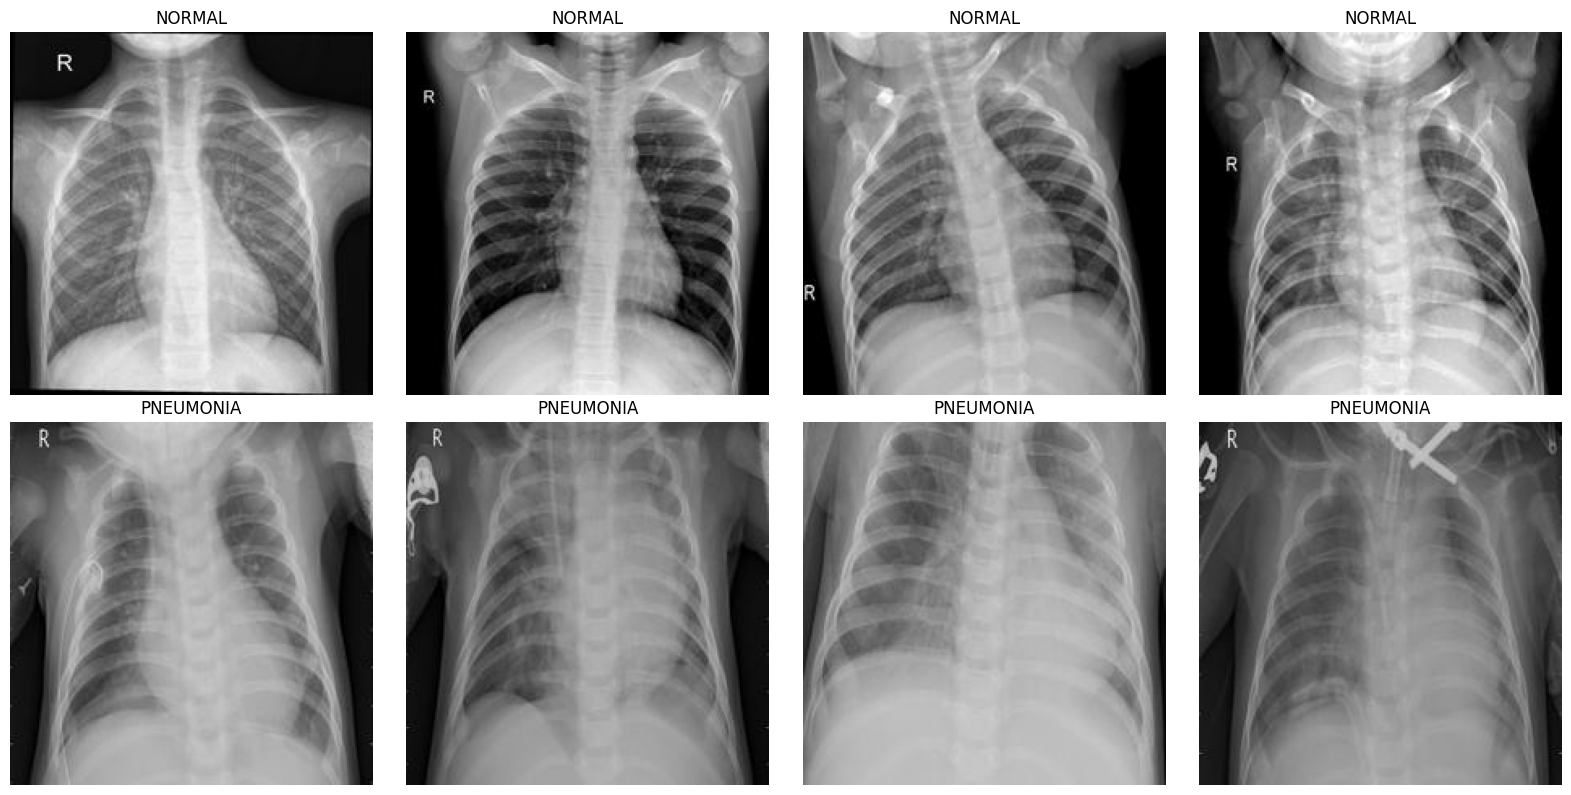

In [46]:
# Cell 7 — Show sample images

def show_sample_images(samples, n_per_class=2):
    fig, axes = plt.subplots(
        len(CLASS_NAMES),
        n_per_class,
        figsize=(4 * n_per_class, 4 * len(CLASS_NAMES))
    )

    for class_name in CLASS_NAMES:
        class_idx = CLASS_NAMES.index(class_name)
        class_samples = [path for path, y in samples if y == class_idx]

        if len(class_samples) == 0:
            continue

        chosen_paths = random.sample(
            class_samples,
            min(n_per_class, len(class_samples))
        )

        for i, image_path in enumerate(chosen_paths):
            image = Image.open(image_path)
            axes[class_idx, i].imshow(image, cmap="gray")
            axes[class_idx, i].set_title(class_name)
            axes[class_idx, i].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(unbalanced_train_samples, n_per_class=4)

### Aplicação das Técnicas de Aprendizado de Máquina

Para a etapa de classificação foi adotada uma abordagem baseada em redes neurais convolucionais, por serem modelos adequados para tarefas de reconhecimento de padrões em imagens. Esse tipo de arquitetura permite a extração automática de características visuais relevantes, como bordas, texturas, formas e padrões locais, reduzindo a necessidade de definição manual de atributos.

O modelo escolhido foi o MobileNetV2, uma arquitetura eficiente, projetada para apresentar bom desempenho com baixo custo computacional. Sua utilização é adequada ao problema proposto, pois combina capacidade de extração de características com leveza em termos de número de parâmetros e operações, tornando o treinamento e a inferência mais viáveis mesmo em ambientes com recursos limitados.

Neste trabalho, foi utilizado o modelo MobileNetV2 com pesos pré-treinados disponibilizados pelo PyTorch/TorchVision. Esses pesos foram originalmente treinados sobre o conjunto ImageNet, permitindo o uso de aprendizado por transferência. Dessa forma, as camadas iniciais do modelo já possuem filtros capazes de identificar padrões visuais genéricos, enquanto as camadas finais podem ser adaptadas para a tarefa específica de classificação entre imagens normais e imagens com pneumonia.

Além disso, foi aplicado o pré-processamento padrão associado aos pesos pré-treinados do MobileNetV2 no TorchVision. Esse procedimento inclui o redimensionamento da imagem, seguido de um recorte central para a dimensão de entrada esperada pelo modelo, principalmente ajustando as imagens para 224 × 224 pixels. Em seguida, os valores dos pixels são reescalados e normalizados com médias e desvios-padrão compatíveis com o treinamento original no ImageNet.

A documentação indica que MobileNet_V2_Weights.DEFAULT corresponde aos pesos IMAGENET1K_V2, com cerca de 3,5 milhões de parâmetros, 0,30 GFLOPS e tamanho aproximado de 13,6 MB. Para esses pesos, as transformações fazem resize com crop central para 224 pixels e normalização com mean=[0.485, 0.456, 0.406] e std=[0.229, 0.224, 0.225].


In [47]:

unbalanced_weights = MobileNet_V2_Weights.DEFAULT
unbalanced_preprocess = unbalanced_weights.transforms()

unbalanced_train_dataset = ChestXRayDataset(unbalanced_train_samples, transform=unbalanced_preprocess)
unbalanced_val_dataset = ChestXRayDataset(unbalanced_val_samples, transform=unbalanced_preprocess)
unbalanced_test_dataset = ChestXRayDataset(unbalanced_test_samples, transform=unbalanced_preprocess)

print("Dimensões da imagem após transformação:", unbalanced_train_dataset[0][0].shape)

Dimensões da imagem após transformação: torch.Size([3, 224, 224])


A classe `Dataset` armazena as amostras e seus labels correspondentes, e `DataLoader` envolve o `Dataset` em um iterável para permitir acesso fácil às amostras. Os seguinte parâmetros são utilizados:

`dataset` (`Dataset`) – conjunto de dados a partir do qual os dados serão carregados.

`batch_size` (`int`, opcional) – quantas amostras carregar por lote/batch. Padrão: `1`.

`shuffle` (`bool`, opcional) – defina como `True` para que os dados sejam embaralhados novamente a cada época. Padrão: `False`.

`num_workers` (`int`, opcional) – quantos subprocessos usar para o carregamento dos dados. `0` significa que os dados serão carregados no processo principal. Padrão: `0`.

`pin_memory` (`bool`, opcional) – se `True`, o data loader copiará os Tensores para memória fixada do dispositivo/CUDA antes de retorná-los.

In [48]:
pin_memory = torch.cuda.is_available()

unbalanced_train_loader = DataLoader(
    unbalanced_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

unbalanced_val_loader = DataLoader(
    unbalanced_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

unbalanced_test_loader = DataLoader(
    unbalanced_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

Faz transfer learning com a MobileNetV2: carrega um modelo pré-treinado, congela suas camadas principais e substitui a camada final para adaptar o modelo à classificação binária entre raio-X normal e raio-X com pneumonia.

A última camada é trocada por uma camada linear com apenas 1 neurônio de saída.

In [49]:
unbalanced_model = models.mobilenet_v2(weights=unbalanced_weights)
for param in unbalanced_model.parameters():
    param.requires_grad = False
unbalanced_model.classifier[1] = nn.Linear(unbalanced_model.classifier[1].in_features, 1)

unbalanced_model = unbalanced_model.to(device)


trainable_params = sum(p.numel() for p in unbalanced_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in unbalanced_model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 1281
Total parameters: 2225153


### Treinamento da RN no dataset desbalanceado

O *early stopping* interrompe o treinamento quando a perda não melhora por várias épocas.

Neste notebook:

- `MAX_EPOCHS = 20`
- `PATIENCE = 4` (Quantas épocas sem melhoria esperar)

O melhor modelo é salvo automaticamente.

`BCEWithLogitsLoss`: a função de perda usada para medir o erro do modelo. É adequada para classificação binária pois ombina duas etapas em uma só: sigmoid + binary cross-entropy.

`Adam`: o otimizador responsável por atualizar os pesos treináveis do modelo durante o treinamento. É uma variação eficiente do gradiente descendente.

In [50]:
def evaluate_during_training(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

    epoch_loss = running_loss / max(total_samples, 1)
    epoch_accuracy = running_corrects / max(total_samples, 1)

    return epoch_loss, epoch_accuracy

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=20,
    learning_rate=0.001,
    patience=4,
    best_model_path="best_model.pth"
):
    weight = torch.tensor([1.0], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weight)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    amp_enabled = torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_epoch = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1).float()

            optimizer.zero_grad()

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predictions = torch.sigmoid(outputs).round()

            batch_size_current = labels.size(0)
            running_loss += loss.item() * batch_size_current
            running_corrects += torch.sum(predictions == labels).item()
            total_samples += batch_size_current

        train_loss = running_loss / max(total_samples, 1)
        train_accuracy = running_corrects / max(total_samples, 1)

        val_loss, val_accuracy = evaluate_during_training(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {best_epoch}.")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= patience:
            print("Early stopping activated.")
            break

    training_time_seconds = time.time() - start_time
    epochs_done = len(history["train_loss"])

    print("Training complete.")
    print(f"Best epoch: {best_epoch}")
    print(f"Training time: {training_time_seconds:.2f} seconds or {training_time_seconds/60:.2f} minutes")

    return history, training_time_seconds, best_epoch, epochs_done

In [51]:
# Inicia o treinamento

unb_history, unb_training_time_seconds, unb_best_epoch, unb_epochs_done = train_model(
    model=unbalanced_model,
    train_loader=unbalanced_train_loader,
    val_loader=unbalanced_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=UNBALANCED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.3619, Train Acc: 0.8305, Val Loss: 0.3903, Val Acc: 0.8180
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2357, Train Acc: 0.9108, Val Loss: 0.2939, Val Acc: 0.8740
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.2073, Train Acc: 0.9222, Val Loss: 0.2957, Val Acc: 0.8580
No improvement for 1 epoch(s).
Epoch [4/20], Train Loss: 0.1902, Train Acc: 0.9298, Val Loss: 0.2647, Val Acc: 0.8760
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.1748, Train Acc: 0.9322, Val Loss: 0.2158, Val Acc: 0.9180
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.1662, Train Acc: 0.9388, Val Loss: 0.2133, Val Acc: 0.9180
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.1619, Train Acc: 0.9368, Val Loss: 0.1866, Val Acc: 0.9320
Best model saved at epoch 7.
Epoch [8/20], Train Loss: 0.1478, Train Acc: 0.9463, Val Loss: 0.2413, Val Acc: 0.8920
No improvement for 1 epoch(s).
Epoch [9/20], Train Loss: 0.1478, Train Acc: 0.9483, Val Loss: 0.257

### Avaliação dos Resultados

Exibe as curvas de treinamento:

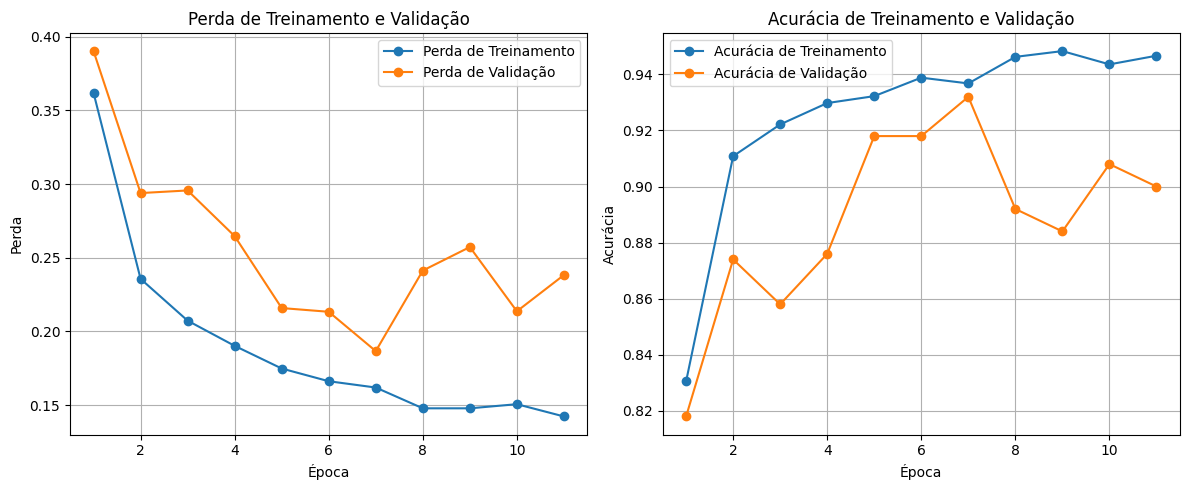

In [52]:
def plot_training_curves(history):
    
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Perda de Treinamento")
    plt.plot(epochs, history["val_loss"], marker="o", label="Perda de Validação")
    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title("Perda de Treinamento e Validação")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], marker="o", label="Acurácia de Treinamento")
    plt.plot(epochs, history["val_accuracy"], marker="o", label="Acurácia de Validação")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.title("Acurácia de Treinamento e Validação")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
plot_training_curves(unb_history)

Carrega o melhor modelo que foi salvo em arquivo:

In [53]:
unbalanced_model.load_state_dict(torch.load(UNBALANCED_BEST_MODEL_PATH, map_location=device, weights_only=True))
unbalanced_model = unbalanced_model.to(device)

print("Loaded best model:", UNBALANCED_BEST_MODEL_PATH)

Loaded best model: trained-models/exp4/best_mobilenetv2_unbalanced.pth


A avaliação dos resultados é feita no conjunto de testes:

Obs.: o threshold é o valor de corte usado para transformar a probabilidade calculada pela rede (entre 0 e 1) em uma decisão final (Pneumonia ou não).

In [54]:
def evaluate_model(model, test_loader, threshold=0.5):
    model.eval()

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            probabilities = torch.sigmoid(outputs).squeeze(1).cpu()
            predictions = (probabilities >= threshold).long()

            all_probabilities.extend(probabilities.tolist())
            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.tolist())

    test_accuracy = accuracy_score(all_labels, all_predictions)
    test_precision = precision_score(all_labels, all_predictions, zero_division=0)
    test_recall = recall_score(all_labels, all_predictions, zero_division=0)
    test_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    return all_labels, all_predictions, all_probabilities


unb_all_labels, unb_all_predictions, unb_all_probabilities = evaluate_model(
    unbalanced_model,
    unbalanced_test_loader,
    threshold=FINAL_THRESHOLD
)

Threshold: 0.5
Test Accuracy: 0.9300
Test Precision: 0.9249
Test Recall: 0.9360
Test F1 Score: 0.9304

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.92      0.93       250
   PNEUMONIA       0.92      0.94      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



#### Refinamento do Threshold

Vamos comparar as métricas para diferentes thresholds.

In [55]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in unb_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(unb_all_labels, preds),
        "precision": precision_score(unb_all_labels, preds, zero_division=0),
        "recall": recall_score(unb_all_labels, preds, zero_division=0),
        "f1_score": f1_score(unb_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.930,0.924901,0.936,0.930417
1,0.55,0.938,0.939759,0.936,0.937876
2,0.60,0.940,0.954545,0.924,0.939024
3,0.65,0.934,0.957806,0.908,0.932238
4,0.70,0.936,0.973913,0.896,0.933333


##### Matriz de confusão

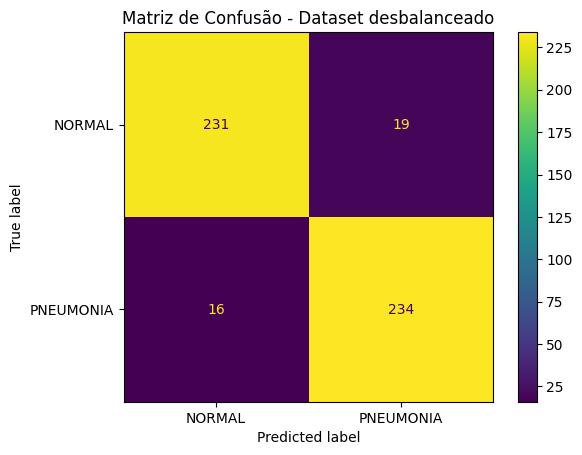

In [56]:
unb_conf_matrix = confusion_matrix(unb_all_labels, unb_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=unb_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset desbalanceado")
plt.show()

### Experimento com o dataset balanceado por UNDERSAMPLING

Neste segundo experimento, o conjunto de **treinamento** e o conjunto de **validação** foram balanceados por undersampling. O conjunto de **teste** foi mantido igual ao dataset desbalanceado, sem undersampling, para que a avaliação final continue sendo feita sobre a mesma distribuição nos dois experimentos.

In [57]:
balanced_train_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "train")
balanced_val_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "val")
balanced_test_samples = read_samples_by_folder(UNDERSAMPLED_DATA_ROOT, "test")

print_class_counts("Train", balanced_train_samples)
print_class_counts("Validation", balanced_val_samples)
print_class_counts("Test", balanced_test_samples)

total_balanced_images = len(balanced_train_samples) + len(balanced_val_samples) + len(balanced_test_samples)
print("Total images used:", total_balanced_images)

Train images: 2166
|--NORMAL: 1083
|--PNEUMONIA: 1083
Validation images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Test images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Total images used: 3166


In [58]:

balanced_weights = MobileNet_V2_Weights.DEFAULT
balanced_preprocess = balanced_weights.transforms()

balanced_train_dataset = ChestXRayDataset(balanced_train_samples, transform=balanced_preprocess)
balanced_val_dataset = ChestXRayDataset(balanced_val_samples, transform=balanced_preprocess)
balanced_test_dataset = ChestXRayDataset(balanced_test_samples, transform=balanced_preprocess)

In [59]:
balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_val_loader = DataLoader(
    balanced_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

balanced_test_loader = DataLoader(
    balanced_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

In [60]:
balanced_model = models.mobilenet_v2(weights=balanced_weights)
for param in balanced_model.parameters():
    param.requires_grad = False
balanced_model.classifier[1] = nn.Linear(balanced_model.classifier[1].in_features, 1)

balanced_model = balanced_model.to(device)


trainable_params = sum(p.numel() for p in balanced_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in balanced_model.parameters())

In [61]:
# Inicia o treinamento

b_history, b_training_time_seconds, b_best_epoch, b_epochs_done = train_model(
    model=balanced_model,
    train_loader=balanced_train_loader,
    val_loader=balanced_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=UNDERSAMPLED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.5154, Train Acc: 0.8121, Val Loss: 0.3898, Val Acc: 0.8860
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.3500, Train Acc: 0.8929, Val Loss: 0.2968, Val Acc: 0.9080
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.3076, Train Acc: 0.8901, Val Loss: 0.2639, Val Acc: 0.9220
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.2787, Train Acc: 0.9035, Val Loss: 0.2458, Val Acc: 0.9160
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.2610, Train Acc: 0.9054, Val Loss: 0.2299, Val Acc: 0.9180
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.2448, Train Acc: 0.9132, Val Loss: 0.2213, Val Acc: 0.9140
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.2417, Train Acc: 0.9141, Val Loss: 0.2160, Val Acc: 0.9180
Best model saved at epoch 7.
Epoch [8/20], Train Loss: 0.2262, Train Acc: 0.9201, Val Loss: 0.2098, Val Acc: 0.9240
Best model saved at epoch 8.
Epoch [9/20], Train Loss: 0.2174, Train Acc: 0.9224, Val Loss: 0.2163, V

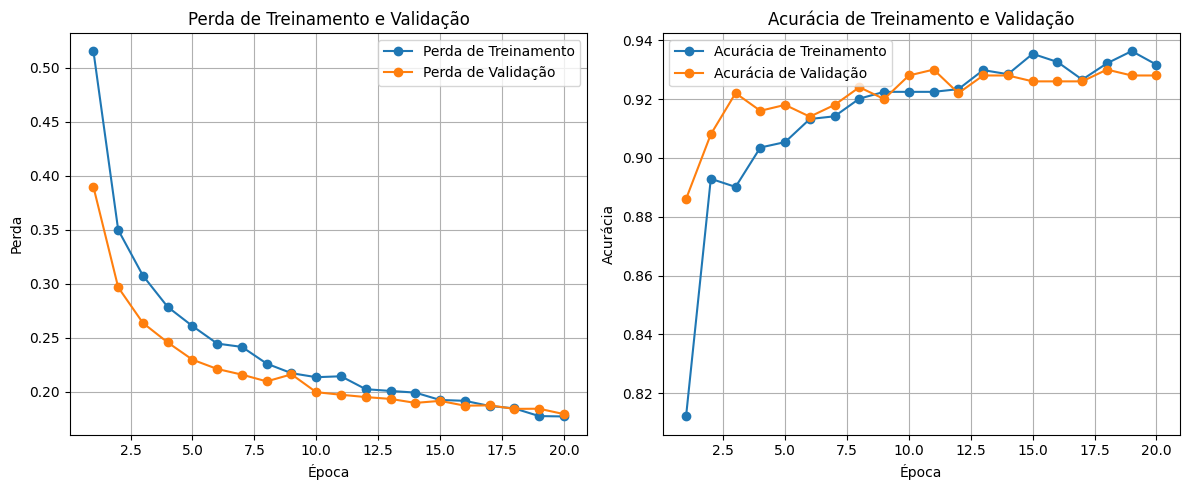

In [62]:
plot_training_curves(b_history)

In [63]:
balanced_model.load_state_dict(torch.load(UNDERSAMPLED_BEST_MODEL_PATH, map_location=device, weights_only=True))
balanced_model = balanced_model.to(device)

print("Loaded best model:", UNDERSAMPLED_BEST_MODEL_PATH)

b_all_labels, b_all_predictions, b_all_probabilities = evaluate_model(
    balanced_model,
    balanced_test_loader,
    threshold=FINAL_THRESHOLD
)

Loaded best model: trained-models/exp4/best_mobilenetv2_undersampled.pth
Threshold: 0.5
Test Accuracy: 0.9380
Test Precision: 0.9544
Test Recall: 0.9200
Test F1 Score: 0.9369

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.96      0.94       250
   PNEUMONIA       0.95      0.92      0.94       250

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



In [64]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in b_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(b_all_labels, preds),
        "precision": precision_score(b_all_labels, preds, zero_division=0),
        "recall": recall_score(b_all_labels, preds, zero_division=0),
        "f1_score": f1_score(b_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.938,0.954357,0.920,0.936864
1,0.55,0.938,0.962025,0.912,0.936345
2,0.60,0.932,0.961538,0.900,0.929752
3,0.65,0.934,0.965665,0.900,0.931677
4,0.70,0.926,0.969163,0.880,0.922432


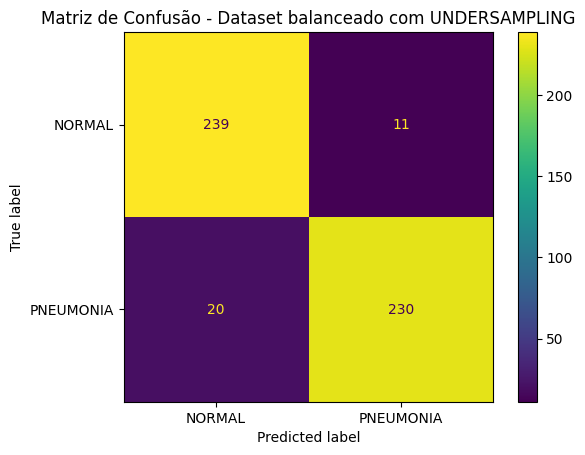

In [65]:
b_conf_matrix = confusion_matrix(b_all_labels, b_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=b_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset balanceado com UNDERSAMPLING")
plt.show()

### Experimento com o dataset balanceado por OVERSAMPLING

Neste terceiro experimento, o conjunto de **treinamento** foi balanceado por oversampling. Os conjuntos de **teste** e **validação** foram mantidos iguais ao dataset desbalanceado, sem oversampling, para que a avaliação final continue sendo feita sobre a mesma distribuição nos dois experimentos.

In [66]:
os_train_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "train")
os_val_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "val")
os_test_samples = read_samples_by_folder(OVERSAMPLED_DATA_ROOT, "test")

print_class_counts("Train", os_train_samples)
print_class_counts("Validation", os_val_samples)
print_class_counts("Test", os_test_samples)

total_os_images = len(os_train_samples) + len(os_val_samples) + len(os_test_samples)
print("Total images used:", total_os_images)

Train images: 7546
|--NORMAL: 3773
|--PNEUMONIA: 3773
Validation images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Test images: 500
|--NORMAL: 250
|--PNEUMONIA: 250
Total images used: 8546


In [67]:

os_weights = MobileNet_V2_Weights.DEFAULT
os_preprocess = os_weights.transforms()

os_train_dataset = ChestXRayDataset(os_train_samples, transform=os_preprocess)
os_val_dataset = ChestXRayDataset(os_val_samples, transform=os_preprocess)
os_test_dataset = ChestXRayDataset(os_test_samples, transform=os_preprocess)

In [68]:
os_train_loader = DataLoader(
    os_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

os_val_loader = DataLoader(
    os_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

os_test_loader = DataLoader(
    os_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

In [69]:
os_model = models.mobilenet_v2(weights=os_weights)
for param in os_model.parameters():
    param.requires_grad = False
os_model.classifier[1] = nn.Linear(os_model.classifier[1].in_features, 1)

os_model = os_model.to(device)

In [70]:
# Inicia o treinamento

os_history, os_training_time_seconds, os_best_epoch, os_epochs_done = train_model(
    model=os_model,
    train_loader=os_train_loader,
    val_loader=os_val_loader,
    num_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    best_model_path=OVERSAMPLED_BEST_MODEL_PATH
)

Epoch [1/20], Train Loss: 0.3731, Train Acc: 0.8748, Val Loss: 0.3016, Val Acc: 0.8980
Best model saved at epoch 1.
Epoch [2/20], Train Loss: 0.2347, Train Acc: 0.9215, Val Loss: 0.2555, Val Acc: 0.9180
Best model saved at epoch 2.
Epoch [3/20], Train Loss: 0.2082, Train Acc: 0.9239, Val Loss: 0.2475, Val Acc: 0.9060
Best model saved at epoch 3.
Epoch [4/20], Train Loss: 0.1872, Train Acc: 0.9332, Val Loss: 0.2323, Val Acc: 0.9140
Best model saved at epoch 4.
Epoch [5/20], Train Loss: 0.1763, Train Acc: 0.9351, Val Loss: 0.2297, Val Acc: 0.9100
Best model saved at epoch 5.
Epoch [6/20], Train Loss: 0.1738, Train Acc: 0.9352, Val Loss: 0.2071, Val Acc: 0.9200
Best model saved at epoch 6.
Epoch [7/20], Train Loss: 0.1721, Train Acc: 0.9378, Val Loss: 0.2184, Val Acc: 0.9160
No improvement for 1 epoch(s).
Epoch [8/20], Train Loss: 0.1596, Train Acc: 0.9442, Val Loss: 0.2181, Val Acc: 0.9140
No improvement for 2 epoch(s).
Epoch [9/20], Train Loss: 0.1583, Train Acc: 0.9418, Val Loss: 0.198

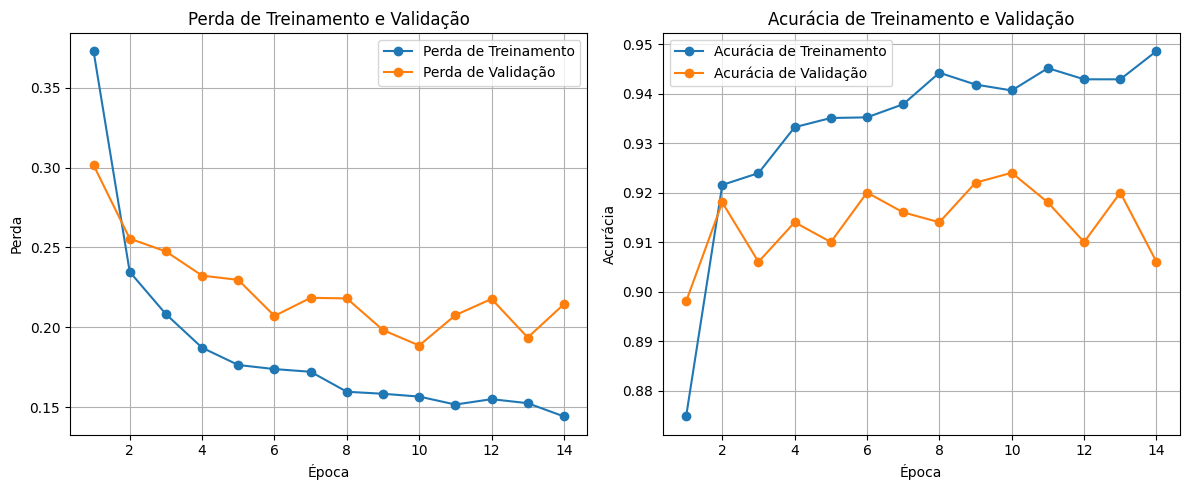

In [71]:
plot_training_curves(os_history)

In [72]:
os_model.load_state_dict(torch.load(OVERSAMPLED_BEST_MODEL_PATH, map_location=device, weights_only=True))
os_model = os_model.to(device)

print("Loaded best model:", OVERSAMPLED_BEST_MODEL_PATH)

os_all_labels, os_all_predictions, os_all_probabilities = evaluate_model(
    os_model,
    os_test_loader,
    threshold=FINAL_THRESHOLD
)

Loaded best model: trained-models/exp4/best_mobilenetv2_oversampled.pth
Threshold: 0.5
Test Accuracy: 0.9260
Test Precision: 0.9312
Test Recall: 0.9200
Test F1 Score: 0.9256

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.93      0.93       250
   PNEUMONIA       0.93      0.92      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



In [73]:
threshold_rows = []

for th in [0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = [1 if p >= th else 0 for p in os_all_probabilities]

    row = {
        "threshold": th,
        "accuracy": accuracy_score(os_all_labels, preds),
        "precision": precision_score(os_all_labels, preds, zero_division=0),
        "recall": recall_score(os_all_labels, preds, zero_division=0),
        "f1_score": f1_score(os_all_labels, preds, zero_division=0),
    }

    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,accuracy,precision,recall,f1_score
0,0.50,0.926,0.931174,0.920,0.925553
1,0.55,0.926,0.941909,0.908,0.924644
2,0.60,0.918,0.944681,0.888,0.915464
3,0.65,0.924,0.960870,0.884,0.920833
4,0.70,0.920,0.960526,0.876,0.916318


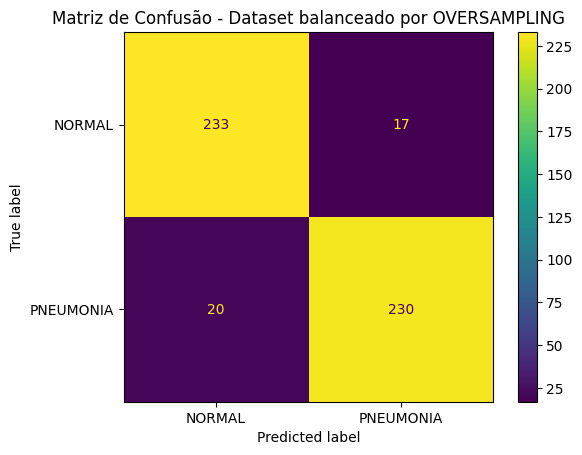

In [74]:
os_conf_matrix = confusion_matrix(os_all_labels, os_all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=os_conf_matrix,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - Dataset balanceado por OVERSAMPLING")
plt.show()